<a href="https://colab.research.google.com/github/rahmamohax/SmartReviewAnalyzer/blob/master/notebooks/06_insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 - Insights Extraction

This notebook extracts and compares insights from the Baseline Model (Naive Bayes + TF-IDF) and the Advanced Model (LSTM).

## 1. Setup and Project Paths

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import load_model
import nltk
from nltk.util import ngrams
from collections import Counter
from sklearn.metrics import confusion_matrix

nltk.download('punkt', quiet=True)
nltk.download('stopwords')
nltk.download('punkt_tab')

from google.colab import drive
drive.mount('/content/drive')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Mounted at /content/drive


In [2]:
# ------------------------
# 📁 PROJECT PATHS
# ------------------------
DRIVE_ROOT    = '/content/drive/MyDrive/SmartReviewAnalyzer'
FEATURES_DIR  = f'{DRIVE_ROOT}/data/features'
PROCESSED_DIR = f'{DRIVE_ROOT}/data/processed'
MODELS_DIR    = f'{DRIVE_ROOT}/models'

OUTPUT_DIR = f'{MODELS_DIR}/insights_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Directories configured.")

Directories configured.


## 2. Load Data and Models
We load the preprocessed datasets, TF-IDF features, and our trained models (without retraining).

In [3]:
# ------------------------
# 📊 DATA SOURCES
# ------------------------
try:
    # Preprocessed datasets
    train_df = pd.read_csv(f'{PROCESSED_DIR}/preprocessed_train.csv')
    test_df  = pd.read_csv(f'{PROCESSED_DIR}/preprocessed_test.csv')

    # TF-IDF Features
    X_train_tfidf = sp.load_npz(f'{FEATURES_DIR}/X_train_tfidf.npz')
    X_test_tfidf  = sp.load_npz(f'{FEATURES_DIR}/X_test_tfidf.npz')
    tfidf_vectorizer = joblib.load(f'{FEATURES_DIR}/tfidf_vectorizer.joblib')

    # Labels
    labels = np.load(f'{FEATURES_DIR}/labels.npz')
    y_train = labels['y_train']
    y_test  = labels['y_test']
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Warning: {e}\nMake sure your drive is mounted and paths are correct if running on Colab.")

# ------------------------
# 🤖 MODELS (LOAD ONLY)
# ------------------------
try:
    # Baseline Model
    baseline_model = joblib.load(f'{MODELS_DIR}/baseline_models/nb_tfidf.joblib')

    # Advanced Model (LSTM)
    advanced_model = load_model(f'{MODELS_DIR}/advanced_lstm_model.keras')
    print("Models loaded successfully.")
except Exception as e:
    print(f"Warning: {e}\nMake sure the models exist at the specified paths.")

Data loaded successfully.
Models loaded successfully.


## 3. Helper Functions
Functions to extract bigrams, analyze patterns, and streamline prediction outputs.

In [4]:
def get_top_ngrams(corpus, n=2, top_k=10):
    """Extracts the most frequent n-grams from a list of texts."""
    all_ngrams = []
    for text in corpus:
        tokens = str(text).split() # Simple whitespace tokenization
        all_ngrams.extend(ngrams(tokens, n))

    ngram_counts = Counter(all_ngrams)
    return ngram_counts.most_common(top_k)

def analyze_patterns(df, text_col='text', label_col='sentiment'):
    """Finds frequent bigrams (patterns) in positive and negative reviews."""
    # Ensure column exists, fallback to 'review' if 'text' isn't there
    if text_col not in df.columns and 'review' in df.columns:
        text_col = 'review'

    pos_reviews = df[df[label_col] == 1][text_col].tolist()
    neg_reviews = df[df[label_col] == 0][text_col].tolist()

    pos_bigrams = get_top_ngrams(pos_reviews, n=2, top_k=10)
    neg_bigrams = get_top_ngrams(neg_reviews, n=2, top_k=10)

    return pos_bigrams, neg_bigrams

def get_predictions(model, X):
    """Helper to standardize prediction outputs for Sklearn vs Keras models."""
    if hasattr(model, 'predict_proba'): # Sklearn model (Baseline)
        probs = model.predict_proba(X)
        preds = np.argmax(probs, axis=1)
        confidences = np.max(probs, axis=1)
        return preds, confidences
    else: # Keras model (Advanced)
        probs = model.predict(X, verbose=0).squeeze()
        # Handle binary classification sigmoid output
        if len(probs.shape) == 1 or probs.shape[1] == 1:
            preds = (probs > 0.5).astype(int)
            confidences = np.where(preds == 1, probs, 1 - probs)
        else: # Handle categorical softmax output
            preds = np.argmax(probs, axis=1)
            confidences = np.max(probs, axis=1)
        return preds, confidences

## 4. Baseline Insights (Naive Bayes + TF-IDF)
We extract feature importance (keywords) directly from the TF-IDF and Naive Bayes model. Then we find frequent bigram phrases for predictions.

In [5]:
print("=== 🔹 BASELINE MODEL INSIGHTS ===\n")

if 'baseline_model' in locals():
    # 1. Keywords (Feature Importance)
    feature_names = tfidf_vectorizer.get_feature_names_out()

    baseline_top_neg_words = []
    baseline_top_pos_words = []

    if hasattr(baseline_model, 'feature_log_prob_'):
        # For MultinomialNB
        neg_class_prob = baseline_model.feature_log_prob_[0]
        pos_class_prob = baseline_model.feature_log_prob_[1]

        top_neg_indices = neg_class_prob.argsort()[-10:][::-1]
        top_pos_indices = pos_class_prob.argsort()[-10:][::-1]

        baseline_top_neg_words = [feature_names[i] for i in top_neg_indices]
        baseline_top_pos_words = [feature_names[i] for i in top_pos_indices]

    print("Top Positive Words:", baseline_top_pos_words)
    print("Top Negative Words:", baseline_top_neg_words)

    # Get Baseline Predictions
    baseline_preds, baseline_conf = get_predictions(baseline_model, X_test_tfidf)
    test_df['baseline_pred'] = baseline_preds
    test_df['baseline_conf'] = baseline_conf

    # 2 & 3. Phrases and Patterns
    pos_bigrams_bl, neg_bigrams_bl = analyze_patterns(test_df, label_col='baseline_pred')

    print("\nFrequent Praise Patterns (Baseline Positive):")
    for bigram, count in pos_bigrams_bl:
        print(f"  - {' '.join(bigram)} ({count})")

    print("\nFrequent Complaint Patterns (Baseline Negative):")
    for bigram, count in neg_bigrams_bl:
        print(f"  - {' '.join(bigram)} ({count})")

    # 4. Statistics
    bl_pos_pct = (baseline_preds == 1).mean() * 100
    bl_neg_pct = (baseline_preds == 0).mean() * 100
    print(f"\nBaseline Predictions: {bl_pos_pct:.1f}% Positive, {bl_neg_pct:.1f}% Negative")

=== 🔹 BASELINE MODEL INSIGHTS ===

Top Positive Words: ['def recommend', 'fifth star', 'perfect lunch', 'perfect compliment', 'soooooo good', 'excellent definitely', 'absolutely recommend', 'full montagu', 'reasonable too', 'delicious favorite']
Top Negative Words: ['instead apologize', 'reply oh', 'ow ow', 'cancel service', 'even deserve', 'complete joke', 'rudely say', 'never business', 'food disgust', 'awful never']

Frequent Praise Patterns (Baseline Positive):
  - of the (8323)
  - and the (6503)
  - in the (6049)
  - on the (4905)
  - it was (4746)
  - and I (4128)
  - to the (3727)
  - for a (3676)
  - for the (3588)
  - I was (3564)

Frequent Complaint Patterns (Baseline Negative):
  - of the (9341)
  - in the (8279)
  - I was (7534)
  - it was (7098)
  - and the (6679)
  - to the (6673)
  - on the (6301)
  - for the (5381)
  - and I (5372)
  - to be (5107)

Baseline Predictions: 50.3% Positive, 49.7% Negative


## 5. Advanced Insights (LSTM)
We evaluate the LSTM model solely based on its predictions on `test_df`. We do NOT use TF-IDF here.

In [8]:
print("=== 🚀 ADVANCED MODEL INSIGHTS (LSTM) ===\n")

if 'advanced_model' in locals():

    text_col = 'text' if 'text' in test_df.columns else 'review'

    try:
        # ------------------------
        # ✅ ALWAYS LOAD BERT EMBEDDINGS
        # ------------------------
        X_test_bert = np.load(
            f'{FEATURES_DIR}/SmartReviewAnalyzer_features/X_test_bert.npy'
        )

        # ------------------------
        # ✅ FIX SHAPE FOR LSTM
        # Expected: (N, 1, 384)
        # ------------------------
        if len(X_test_bert.shape) == 2:
            X_test_bert = X_test_bert.reshape(
                X_test_bert.shape[0], 1, X_test_bert.shape[1]
            )

        # ------------------------
        # ✅ PREDICT
        # ------------------------
        advanced_conf = advanced_model.predict(X_test_bert).flatten()
        advanced_preds = (advanced_conf > 0.5).astype(int)

        # ------------------------
        # ✅ STORE RESULTS
        # ------------------------
        test_df['advanced_pred'] = advanced_preds
        test_df['advanced_conf'] = advanced_conf
        test_df['actual_label'] = y_test

        # ------------------------
        # ✅ CATEGORIZE (TP / TN / FP / FN)
        # ------------------------
        test_df['advanced_category'] = 'Unknown'

        test_df.loc[
            (test_df['actual_label'] == 1) & (test_df['advanced_pred'] == 1),
            'advanced_category'
        ] = 'True Positive'

        test_df.loc[
            (test_df['actual_label'] == 0) & (test_df['advanced_pred'] == 0),
            'advanced_category'
        ] = 'True Negative'

        test_df.loc[
            (test_df['actual_label'] == 0) & (test_df['advanced_pred'] == 1),
            'advanced_category'
        ] = 'False Positive'

        test_df.loc[
            (test_df['actual_label'] == 1) & (test_df['advanced_pred'] == 0),
            'advanced_category'
        ] = 'False Negative'

        # ------------------------
        # ✅ PRINT SUMMARY
        # ------------------------
        print("LSTM Prediction Accuracy Categories:")
        print(test_df['advanced_category'].value_counts())

        # ------------------------
        # 🔥 MOST CONFIDENT EXAMPLES
        # ------------------------
        print("\nMost Confident Positive Prediction (LSTM):")
        conf_pos = test_df[test_df['advanced_pred'] == 1] \
            .sort_values(by='advanced_conf', ascending=False).head(1)

        if not conf_pos.empty:
            print(f"Text: {conf_pos[text_col].values[0]}")
            print(f"Confidence: {conf_pos['advanced_conf'].values[0]:.4f}")

        print("\nMost Confident Negative Prediction (LSTM):")
        conf_neg = test_df[test_df['advanced_pred'] == 0] \
            .sort_values(by='advanced_conf', ascending=False).head(1)

        if not conf_neg.empty:
            print(f"Text: {conf_neg[text_col].values[0]}")
            print(f"Confidence: {conf_neg['advanced_conf'].values[0]:.4f}")

        # ------------------------
        # 📊 PATTERN EXTRACTION
        # ------------------------
        tp_corpus = test_df[
            test_df['advanced_category'] == 'True Positive'][text_col].tolist()

        tn_corpus = test_df[
            test_df['advanced_category'] == 'True Negative'][text_col].tolist()

        tp_bigrams = get_top_ngrams(tp_corpus)
        tn_bigrams = get_top_ngrams(tn_corpus)

        print("\n🔥 Frequent Praise Patterns (TP):")
        for bigram, count in tp_bigrams[:10]:
            print(f"  - {' '.join(bigram)} ({count})")

        print("\n❌ Frequent Complaint Patterns (TN):")
        for bigram, count in tn_bigrams[:10]:
            print(f"  - {' '.join(bigram)} ({count})")

        print("\n✅ Advanced insights completed successfully.")

    except Exception as e:
        print(f"❌ LSTM prediction failed: {e}")
        print("\n💡 Checklist:")
        print("- Ensure X_test_bert.npy exists in features folder")
        print("- Ensure shape is (N, 384)")
        print("- Model expects (N, 1, 384)")

=== 🚀 ADVANCED MODEL INSIGHTS (LSTM) ===

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step
LSTM Prediction Accuracy Categories:
advanced_category
True Negative     18145
True Positive     17969
False Negative     2022
False Positive     1836
Name: count, dtype: int64

Most Confident Positive Prediction (LSTM):
Text: Best movers ever!  Seriously.  My husband and I have moved over 20 times with work.  We have used movers all over the country, paid a lot on some moves for the big name movers.  Umbrella Movers beats them all.  They were careful with our boxes, Paul organized and packed the truck brilliantly and the other guys, Nick and Hollis, were smart, professional, hard workers.  Most relaxed I've ever been during a move.  They took pride in their work and were a pleasure to be around.  Would definitely recommend these guys and wish that we could use them for all of our moves.  Thanks so much for making it a pleasant experience guys!  All the best, Mike and Marilyn
Confidence: 1.0000

Most

## 6. Comparison & Visualizations
Visualizing Keywords, Sentiment Distributions, and Confusion Matrices.

=== 📊 COMPARISON & VISUALIZATIONS ===



/tmp/ipykernel_5267/1512389089.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[1]*len(baseline_top_pos_words), y=baseline_top_pos_words, ax=ax[0], orient='h', palette='Greens_r')
/tmp/ipykernel_5267/1512389089.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[1]*len(baseline_top_neg_words), y=baseline_top_neg_words, ax=ax[1], orient='h', palette='Reds_r')


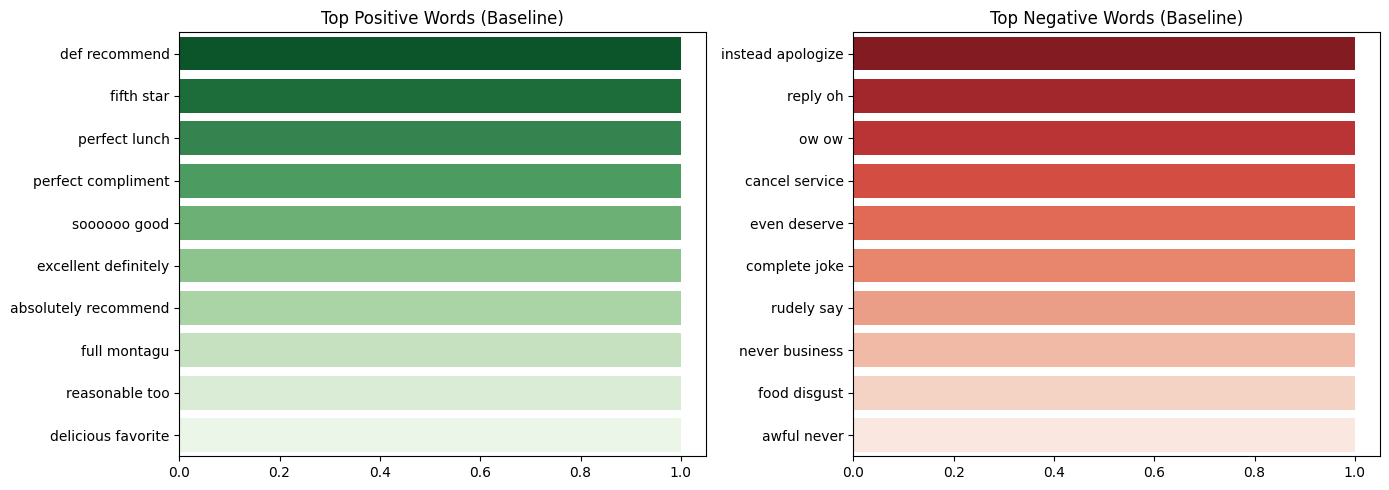

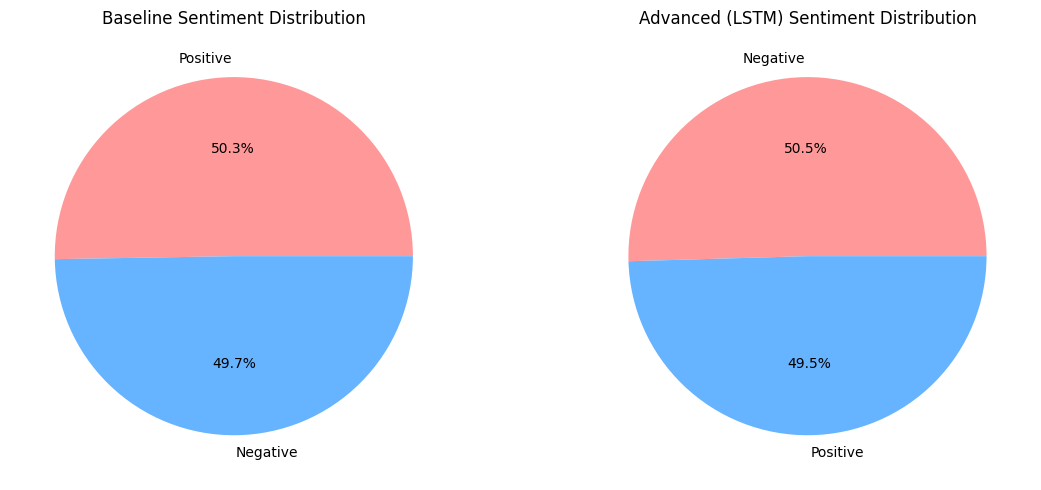

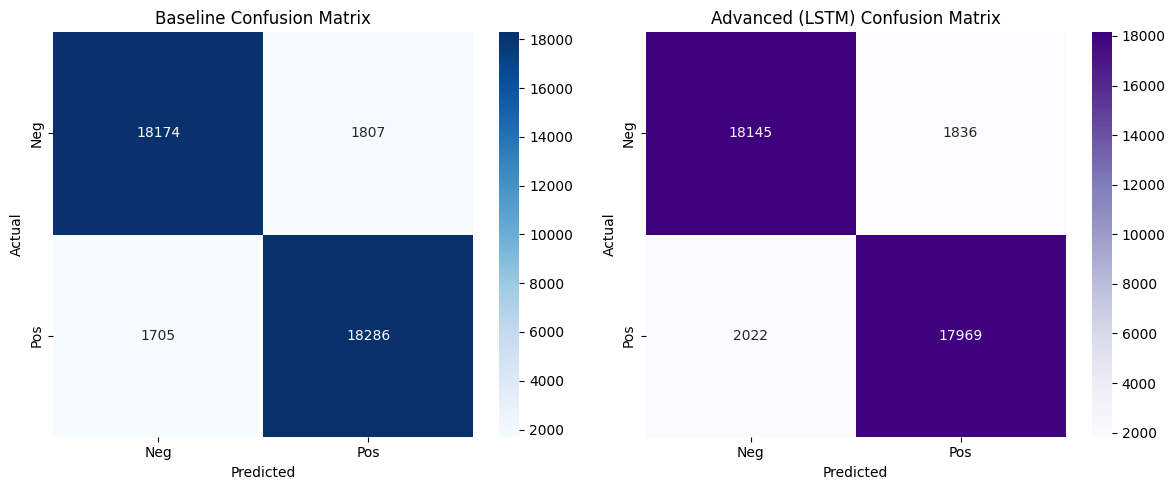

In [9]:
print("=== 📊 COMPARISON & VISUALIZATIONS ===\n")
if 'baseline_model' in locals():
    # 1. Bar Chart: Top Keywords (Baseline)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    if len(baseline_top_pos_words) > 0:
        sns.barplot(x=[1]*len(baseline_top_pos_words), y=baseline_top_pos_words, ax=ax[0], orient='h', palette='Greens_r')
        ax[0].set_title('Top Positive Words (Baseline)')

    if len(baseline_top_neg_words) > 0:
        sns.barplot(x=[1]*len(baseline_top_neg_words), y=baseline_top_neg_words, ax=ax[1], orient='h', palette='Reds_r')
        ax[1].set_title('Top Negative Words (Baseline)')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/baseline_keywords.png')
    plt.show()

if 'advanced_model' in locals() and 'baseline_model' in locals():
    # 2. Pie Chart: Sentiment Distribution
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    bl_counts = test_df['baseline_pred'].value_counts()
    bl_labels = ['Negative', 'Positive'] if bl_counts.index[0] == 0 else ['Positive', 'Negative']
    ax[0].pie(bl_counts, labels=bl_labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
    ax[0].set_title('Baseline Sentiment Distribution')

    if 'advanced_pred' in test_df.columns:
        adv_counts = test_df['advanced_pred'].value_counts()
        adv_labels = ['Negative', 'Positive'] if adv_counts.index[0] == 0 else ['Positive', 'Negative']
        ax[1].pie(adv_counts, labels=adv_labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
        ax[1].set_title('Advanced (LSTM) Sentiment Distribution')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/sentiment_distribution.png')
    plt.show()

    # 3. Comparison Chart: Confusion Matrices
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    cm_bl = confusion_matrix(test_df['actual_label'], test_df['baseline_pred'])
    sns.heatmap(cm_bl, annot=True, fmt='d', cmap='Blues', ax=ax[0], xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
    ax[0].set_title('Baseline Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    if 'advanced_pred' in test_df.columns:
        cm_adv = confusion_matrix(test_df['actual_label'], test_df['advanced_pred'])
        sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Purples', ax=ax[1], xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
        ax[1].set_title('Advanced (LSTM) Confusion Matrix')
        ax[1].set_xlabel('Predicted')
        ax[1].set_ylabel('Actual')

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/confusion_matrices.png')
    plt.show()

## 7. Explanation System
A simple function to predict sentiment on a new review and explain the reasoning based on extracted patterns.

In [10]:
from sentence_transformers import SentenceTransformer

# Load the same embedding model used during training
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_bert_embedding(text):
    # 1. Generate the 384-dim vector
    vector = embedding_model.encode([text])
    # 2. Reshape to (1, 1, 384) to match LSTM input [batch, timesteps, features]
    return vector.reshape(1, 1, 384)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
import random
import numpy as np

def extract_reasons(text, pos_phrases, neg_phrases, pos_words, neg_words):
    text_lower = text.lower()
    reasons = []

    # Prioritize exact phrase patterns
    for item in neg_phrases + pos_phrases:
        # Safely handle tuples from our n-gram analysis vs plain strings
        bg = item[0] if isinstance(item, tuple) and len(item) == 2 and isinstance(item[1], int) else item
        bg_str = ' '.join(bg) if isinstance(bg, tuple) else str(bg)
        if bg_str in text_lower:
            reasons.append(bg_str)

    # Include single keywords if fewer than 2 reasons were found
    if len(reasons) < 2:
        # our word lists are flat strings, not tuples
        for kw in neg_words + pos_words:
            if kw in text_lower:
                reasons.append(kw)

    # Deduplicate and format
    reasons = list(dict.fromkeys(reasons))[:3]
    return ", ".join(reasons) if reasons else "General context (no exact keyword match)"

def safe_print(text):
    try:
        print(str(text).encode('utf-8', 'ignore').decode('utf-8'))
    except:
        print("[Unprintable text]")

def generate_explanation(test_idx, model_type='advanced'):
    """
    Outputs the predicted sentiment and reason for a specific test set instance.
    No manual strings allowed.
    """
    if test_idx < 0 or test_idx >= len(test_df):
        return "Index out of bounds."

    text_col = 'text' if 'text' in test_df.columns else 'review'
    review = test_df.iloc[test_idx][text_col]

    actual_label = test_df.iloc[test_idx]['actual_label']
    true_label = "Positive" if actual_label == 1 else "Negative"

    if model_type == 'baseline':
        pred = test_df.iloc[test_idx]['baseline_pred']
        pos_phrases = pos_bigrams_bl if 'pos_bigrams_bl' in globals() else []
        neg_phrases = neg_bigrams_bl if 'neg_bigrams_bl' in globals() else []
        pos_words = baseline_top_pos_words if 'baseline_top_pos_words' in globals() else []
        neg_words = baseline_top_neg_words if 'baseline_top_neg_words' in globals() else []
    else:
        pred = test_df.iloc[test_idx]['advanced_pred']
        pos_phrases = tp_bigrams if 'tp_bigrams' in globals() else []
        neg_phrases = tn_bigrams if 'tn_bigrams' in globals() else []
        pos_words = baseline_top_pos_words if 'baseline_top_pos_words' in globals() else []
        neg_words = baseline_top_neg_words if 'baseline_top_neg_words' in globals() else []

    predicted_sentiment = "Positive" if pred == 1 else "Negative"

    # Match the review text against the patterns extracted from the test set evaluation
    reason = extract_reasons(
        review,
        pos_phrases,
        neg_phrases,
        pos_words,
        neg_words
    )

    print(f"\n{'='*40}")
    print(f"EXPLANATION ({model_type.upper()}) | Test Index: {test_idx}")
    print(f"{'='*40}")
    print("Review text:")
    safe_print(review)
    print(f"True Sentiment: {true_label}")
    print(f"→ Predicted Sentiment: {predicted_sentiment}")
    print(f"→ Reason: {reason}")
    return predicted_sentiment, reason

# =========================================
# Evaluate Random Correct Predictions
# =========================================
if 'advanced_pred' in test_df.columns and 'actual_label' in test_df.columns:
    print("Generating test explanations for randomized CORRECT predictions...\n")

    correct_ilocs = np.where(test_df['advanced_pred'] == test_df['actual_label'])[0].tolist()

    # Shuffle each time it runs
    random.shuffle(correct_ilocs)

    # Pick top 5 for display
    sample_ilocs = correct_ilocs[:3]

    for idx in sample_ilocs:
        generate_explanation(test_idx=idx, model_type='baseline')
        generate_explanation(test_idx=idx, model_type='advanced')
else:
    print("Predictions not found. Run model evaluation cells first.\n")


Generating test explanations for randomized CORRECT predictions...


EXPLANATION (BASELINE) | Test Index: 30766
Review text:
Service was good but food was tasteless.  Called in advance to ask if they had a bloody mary bar and was told yes.  Upon arrival we were told it was offered only on holidays.  Dissapointed!
True Sentiment: Negative
→ Predicted Sentiment: Negative
→ Reason: it was

EXPLANATION (ADVANCED) | Test Index: 30766
Review text:
Service was good but food was tasteless.  Called in advance to ask if they had a bloody mary bar and was told yes.  Upon arrival we were told it was offered only on holidays.  Dissapointed!
True Sentiment: Negative
→ Predicted Sentiment: Negative
→ Reason: it was

EXPLANATION (BASELINE) | Test Index: 37395
Review text:
Do not go here, they charge too much for what you get and rip you off with the ion foot detox, which is a total hoax, these guys should be put out of business.
True Sentiment: Negative
→ Predicted Sentiment: Negative
→ Reason: Genera